In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_probe = pd.read_csv("results_statistic_probe.csv")
df_probe

,dataset,statistic_type,memory_budget,build_window_size_sec,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,...,build_windows_per_probe_window,num_probe_tuples,num_probe_repetitions,probe_throughput_listener,probe_duration_s,probe_latency_listener,build_throughput_listener,build_duration_s,build_latency_listener,issue
0,ClusterMonitoring,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,1,1000,10000.0,0.566954,9.100000e-07,1.783354e+06,11.185363,3.609849e-07,ok
1,ClusterMonitoring,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,1,1000,10000.0,0.566611,8.900000e-07,1.770710e+06,11.245689,3.987141e-07,ok
2,ClusterMonitoring,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,1,1000,10000.0,0.577361,8.900000e-07,1.756937e+06,11.224989,4.104257e-07,ok
3,ClusterMonitoring,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,100,1,1000,10000.0,0.573527,6.000000e-07,1.773587e+06,11.186329,4.215752e-07,ok
4,ClusterMonitoring,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,100,1,1000,10000.0,0.570603,7.600000e-07,1.806189e+06,10.972518,3.594328e-07,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,ClusterMonitoring,CountMin,10240,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1,1000,100000.0,0.560133,2.952500e-06,1.116059e+07,3.485872,2.721975e-06,ok
284,ClusterMonitoring,CountMin,10240,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1,1000,100000.0,0.567302,2.007500e-06,1.049405e+07,3.607914,2.836012e-06,ok
285,ClusterMonitoring,CountMin,10240,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,100,1,1000,100000.0,0.561929,1.917500e-06,1.083135e+07,3.561674,3.378585e-06,ok
286,ClusterMonitoring,CountMin,10240,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,100,1,1000,100000.0,0.564162,1.437500e-05,1.092104e+07,3.482111,3.333523e-06,ok


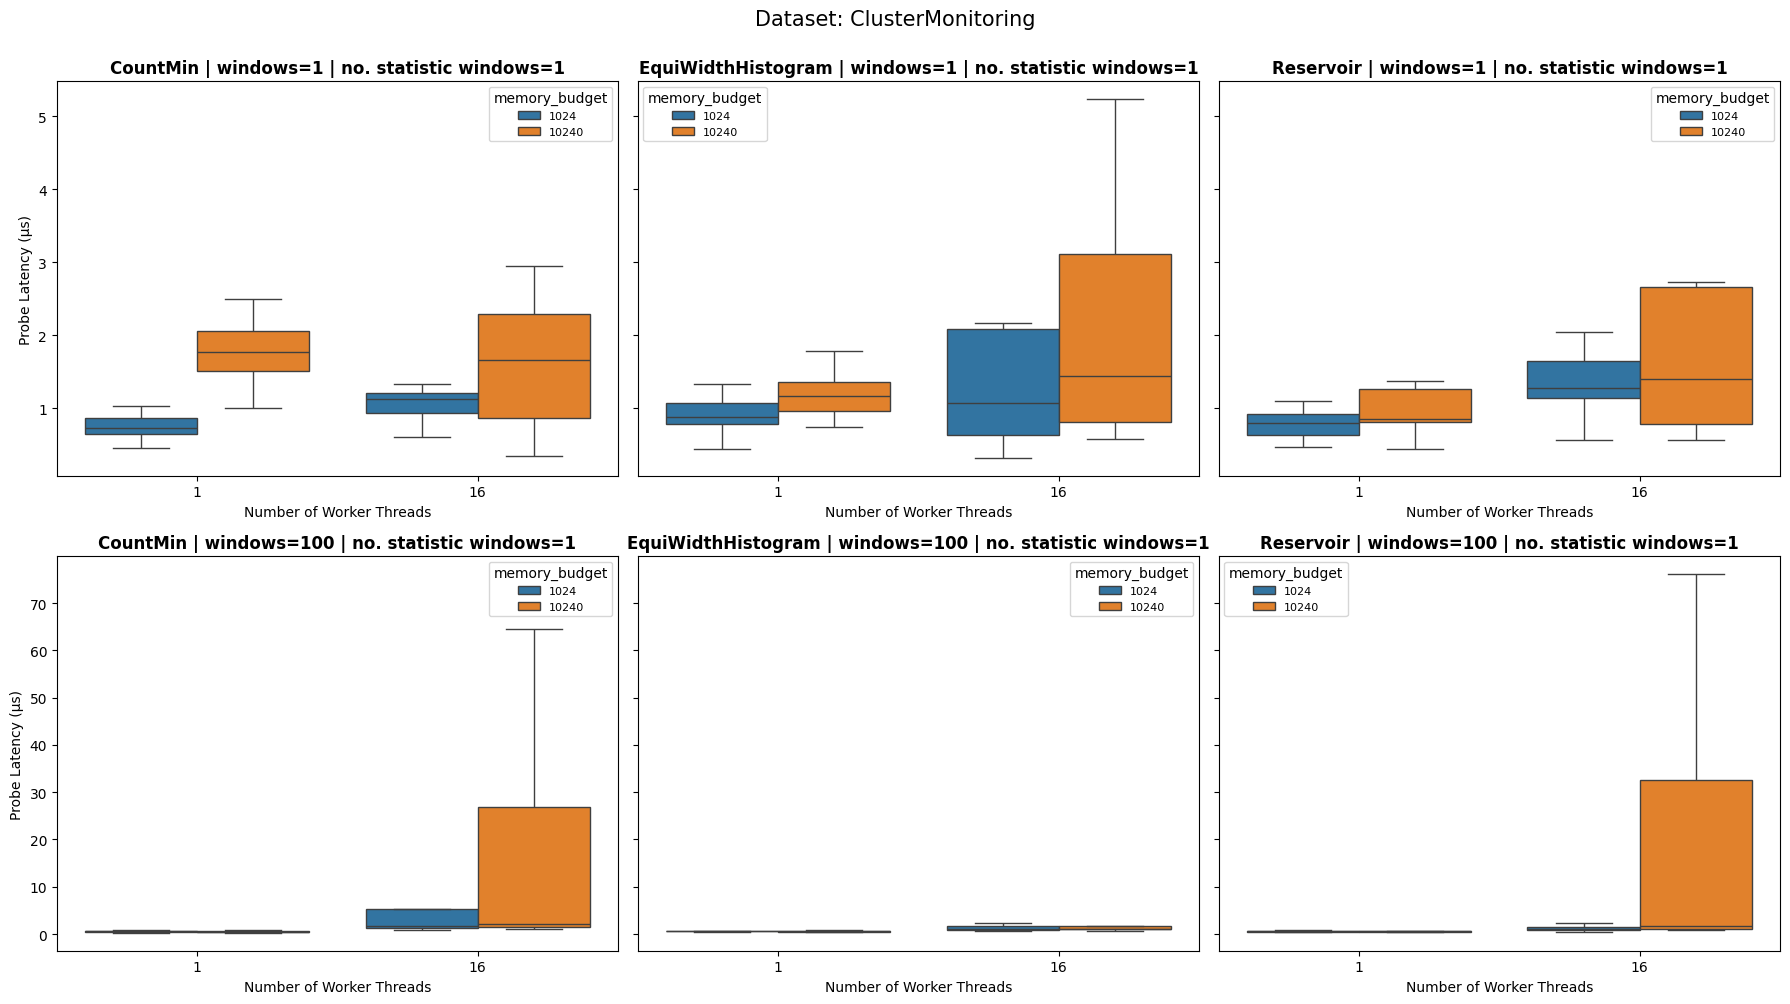

In [2]:
# For each unique dataset, plot a grid:
#   rows  = (build_windows_per_probe_window, num_probe_tuples)
#   cols  = statistic_type
#   x     = numberOfWorkerThreads
#   y     = probe_latency_us
#   hue   = memory_budget
# Aggregates over build_window_size_sec, num_statistic_ids, num_probe_repetitions, run_idx.

df_ok = df_probe[(df_probe["issue"] == "ok") & (df_probe["enableLatency"] == True)].copy()
df_ok["probe_latency_listener"] = pd.to_numeric(df_ok["probe_latency_listener"], errors="coerce")
df_ok = df_ok.dropna(subset=["probe_latency_listener"])
df_ok["probe_latency_us"] = df_ok["probe_latency_listener"] * 1_000_000.0

# Per-row y-axis upper bound: shared across cols within a row, independent across rows.
# Add headroom for the std error bar so the whisker is not clipped.
_means = df_ok.groupby(
    ["dataset", "build_windows_per_probe_window", "num_probe_tuples",
     "statistic_type", "memory_budget", "numberOfWorkerThreads"]
)["probe_latency_us"].agg(["mean", "std"]).fillna(0)
_row_top = (_means["mean"] + _means["std"]).groupby(
    level=["dataset", "build_windows_per_probe_window", "num_probe_tuples"]
).max() * 1

for dataset in sorted(df_ok["dataset"].unique()):
    df_ds = df_ok[df_ok["dataset"] == dataset]

    row_pairs = sorted(
        df_ds[["build_windows_per_probe_window", "num_probe_tuples"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    statistic_types = sorted(df_ds["statistic_type"].unique())

    n_rows = len(row_pairs)
    n_cols = len(statistic_types)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        sharey="row",
        squeeze=False,
    )

    for row_idx, (bwpw, npt) in enumerate(row_pairs):
        row_ymax = _row_top.loc[(dataset, bwpw, npt)]
        for col_idx, stat_type in enumerate(statistic_types):
            ax = axes[row_idx][col_idx]
            subset = df_ds[
                (df_ds["build_windows_per_probe_window"] == bwpw)
                & (df_ds["num_probe_tuples"] == npt)
                & (df_ds["statistic_type"] == stat_type)
            ]

            if subset.empty:
                ax.set_visible(False)
                continue

            hue_order = sorted(subset["memory_budget"].dropna().unique())
            sns.boxplot(
                data=subset,
                x="numberOfWorkerThreads",
                y="probe_latency_us",
                hue="memory_budget",
                hue_order=hue_order,
                palette=sns.color_palette("tab10", len(hue_order)),
                showfliers=False,
                ax=ax,
            )

            #ax.set_ylim(0, row_ymax)
            ax.set_title(f"{stat_type} | windows={bwpw} | no. statistic windows={npt}", fontsize=12, fontweight="bold")
            ax.set_xlabel("Number of Worker Threads")
            ax.set_ylabel("Probe Latency (μs)" if col_idx == 0 else "")
            ax.legend(title="memory_budget", fontsize=8, loc="best")

    fig.suptitle(f"Dataset: {dataset}", fontsize=15, y=1.00)
    plt.tight_layout()
    plt.show()

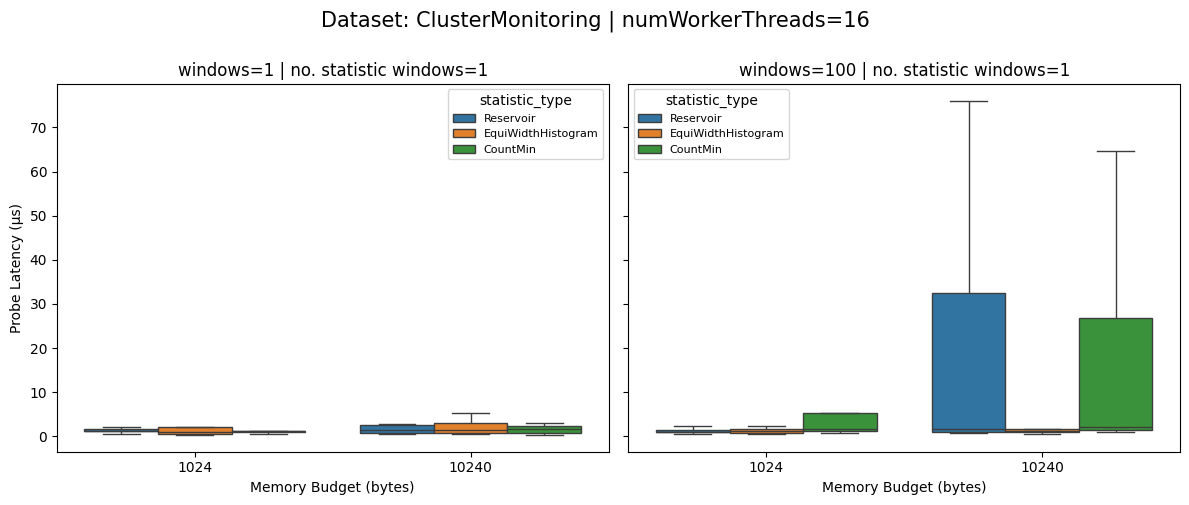

In [3]:
# build_windows_per_probe_window vs probe_latency_us at numberOfWorkerThreads=16.
# One figure per (dataset, num_probe_tuples) pair. Cols = build_windows_per_probe_window, hue = statistic_type.
df16 = df_ok[df_ok["numberOfWorkerThreads"].astype(str) == "16"].copy()

for dataset in sorted(df16["dataset"].unique()):
    df_ds = df16[df16["dataset"] == dataset]
    for npt in sorted(df_ds["num_probe_tuples"].unique()):
        df_dst = df_ds[df_ds["num_probe_tuples"] == npt]
        col_values = sorted(df_dst["build_windows_per_probe_window"].unique())
        n_cols = len(col_values)
        fig, axes = plt.subplots(
            1, n_cols,
            figsize=(6 * n_cols, 5),
            sharey=True,
            squeeze=False,
        )
        for col_idx, bwpw in enumerate(col_values):
            ax = axes[0][col_idx]
            subset = df_dst[df_dst["build_windows_per_probe_window"] == bwpw]
            if subset.empty:
                ax.set_visible(False)
                continue
            sns.boxplot(
                data=subset, x="memory_budget", y="probe_latency_us",
                hue="statistic_type", showfliers=False, ax=ax,
            )
            ax.set_xlabel("Memory Budget (bytes)")
            ax.set_ylabel("Probe Latency (μs)" if col_idx == 0 else "")
            ax.set_title(f"windows={bwpw} | no. statistic windows={npt}")
            ax.legend(title="statistic_type", fontsize=8)
        fig.suptitle(f"Dataset: {dataset} | numWorkerThreads=16", fontsize=15, y=1.00)
        plt.tight_layout()
        plt.show()

In [4]:
df16 = df_ok[df_ok["numberOfWorkerThreads"].astype(str) == "16"].copy()
df16 = df16[df16["dataset"] == "ClusterMonitoring"]
df16 = df16[df16["build_windows_per_probe_window"] == 1]
df16 = df16[df16["num_probe_tuples"] == 1]
df16 = df16[df16["statistic_type"] == "EquiWidthHistogram"]
df16

,dataset,statistic_type,memory_budget,build_window_size_sec,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,...,num_probe_tuples,num_probe_repetitions,probe_throughput_listener,probe_duration_s,probe_latency_listener,build_throughput_listener,build_duration_s,build_latency_listener,issue,probe_latency_us
120,ClusterMonitoring,EquiWidthHistogram,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,10000.0,0.562191,5.900000e-07,1.374646e+07,2.079412,2.504466e-06,ok,0.59000
121,ClusterMonitoring,EquiWidthHistogram,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,10000.0,0.562730,7.600000e-07,1.284428e+07,2.092218,2.064374e-06,ok,0.76000
122,ClusterMonitoring,EquiWidthHistogram,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,10000.0,0.562573,9.900000e-07,1.237013e+07,2.086222,2.040357e-06,ok,0.99000
126,ClusterMonitoring,EquiWidthHistogram,1024,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,10000.0,0.561225,6.300000e-07,3.015217e+07,1.321768,1.514618e-06,ok,0.63000
127,ClusterMonitoring,EquiWidthHistogram,1024,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,10000.0,0.576410,2.050000e-06,3.205000e+07,1.316200,9.455346e-07,ok,2.05000
128,ClusterMonitoring,EquiWidthHistogram,1024,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,10000.0,0.562530,3.200000e-07,3.118760e+07,1.324014,8.474466e-07,ok,0.32000
132,ClusterMonitoring,EquiWidthHistogram,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,100000.0,0.566937,2.637725e-05,1.500142e+06,13.806166,4.012359e-06,ok,26.37725
133,ClusterMonitoring,EquiWidthHistogram,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,100000.0,0.560050,6.250000e-07,1.566057e+06,13.388742,4.727252e-06,ok,0.62500
134,ClusterMonitoring,EquiWidthHistogram,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,100000.0,0.573353,8.875725e-05,1.504523e+06,13.789873,3.718846e-06,ok,88.75725
138,ClusterMonitoring,EquiWidthHistogram,1024,60,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,1000,100000.0,0.566085,2.162250e-06,1.277894e+07,2.708038,2.881003e-06,ok,2.16225
